# 04 — Semantic Document Retrieval

**Question:** Which documents are most relevant to a natural-language query?

We begin with an interpretable TF-IDF baseline, rank with cosine similarity, evaluate known queries, and optionally compare a dense Sentence Transformer.

## 1. Load the corpus

In a document pipeline these text files would usually come from OCR. Keeping the corpus small lets us inspect every ranking manually.

In [1]:
from pathlib import Path
import csv
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

HERE = Path.cwd()
if not (HERE / 'data').exists():
    HERE = HERE / '04_semantic_retrieval'
DATA, OUTPUT = HERE / 'data', HERE / 'output'
OUTPUT.mkdir(exist_ok=True)
paths = sorted((DATA / 'documents').glob('*.txt'))
names = [path.stem for path in paths]
documents = [path.read_text(encoding='utf-8') for path in paths]
for name, document in zip(names, documents):
    print(f'{name:20} {document[:80]}...')

invoice              Invoice 1042 from Northwind Office Supplies.
The total amount due is EUR 249.00....
letter               Dear Dr. Miller,
Thank you for your recent letter about the historical archive c...
meeting_notes        Computer vision meeting notes.
The team will review OCR evaluation, document cle...
receipt              Corner Market receipt.
Coffee EUR 3.50 and bread EUR 2.20. Total paid: EUR 5.70....
registration_form    Workshop registration form.
Participant name: Alex Morgan. Member ID: 1734. Trac...
travel_policy        Employee travel policy.
Rail tickets, hotels, and local transportation can be re...


## 2. TF-IDF representation

Term frequency rewards words used in a document; inverse document frequency downweights words appearing in many documents. The result is a sparse vector whose dimensions correspond to vocabulary terms or n-grams.

In [2]:
vectorizer = TfidfVectorizer(ngram_range=(1, 2), stop_words='english')
document_vectors = vectorizer.fit_transform(documents)
print('matrix shape:', document_vectors.shape)
print('first vocabulary items:', vectorizer.get_feature_names_out()[:15])

matrix shape: (6, 134)
first vocabulary items: ['00' '00 payment' '1042' '1042 northwind' '1734' '1734 track' '20'
 '20 total' '249' '249 00' '50' '50 bread' '70' 'ada' 'ada morgan']


## 3. Cosine similarity and ranking

Cosine similarity is the dot product of length-normalized vectors. It ranges from -1 to 1 for general vectors and from 0 to 1 for nonnegative TF-IDF vectors. It is a similarity score, not a probability.

In [3]:
def rank_tfidf(query, top_k=3):
    query_vector = vectorizer.transform([query])
    scores = cosine_similarity(query_vector, document_vectors).ravel()
    order = np.argsort(scores)[::-1][:top_k]
    return [(names[index], float(scores[index])) for index in order]

QUERY = 'How do I get my train and hotel costs paid back?'
tfidf_results = rank_tfidf(QUERY, top_k=len(documents))
print('Query:', QUERY)
for rank, (name, score) in enumerate(tfidf_results, 1):
    print(f'{rank}. {name:20} {score:.3f}')

Query: How do I get my train and hotel costs paid back?
1. receipt              0.190
2. travel_policy        0.000
3. registration_form    0.000
4. meeting_notes        0.000
5. letter               0.000
6. invoice              0.000


## 4. Save and visualize the ranking

A saved ranking makes the experiment reproducible. The chart also exposes a common lexical failure: a semantically relevant result can score zero when query and document share no important tokens.

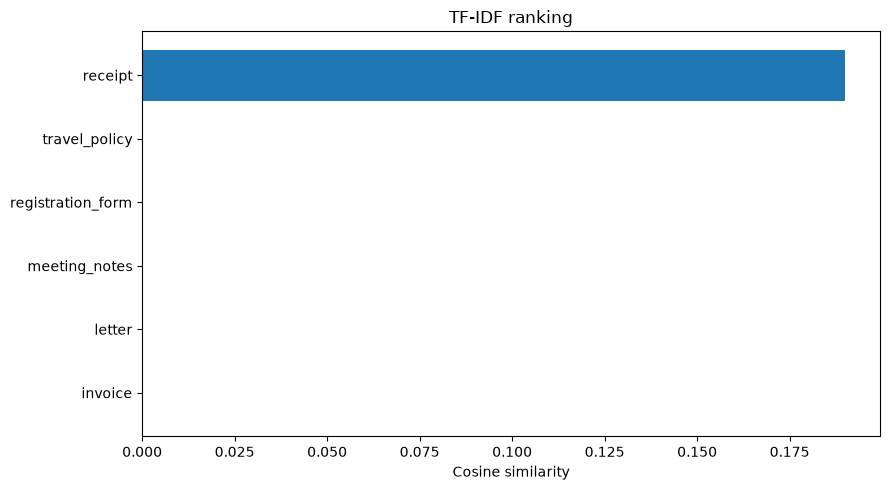

In [4]:
with (OUTPUT / 'rankings.csv').open('w', newline='', encoding='utf-8') as handle:
    writer = csv.writer(handle); writer.writerow(['rank', 'document', 'score', 'query'])
    for rank, (name, score) in enumerate(tfidf_results, 1):
        writer.writerow([rank, name, score, QUERY])
labels = [item[0] for item in tfidf_results][::-1]
scores = [item[1] for item in tfidf_results][::-1]
plt.figure(figsize=(9, 5)); plt.barh(labels, scores); plt.xlabel('Cosine similarity')
plt.title('TF-IDF ranking'); plt.tight_layout(); plt.savefig(OUTPUT / 'similarity_plot.png', dpi=150);

## 5. Evaluate with labeled queries

Recall@k is 1 when the relevant document appears in the first `k` results. Reciprocal rank is `1/rank` for the first relevant result. Averaging over many queries gives Recall@k and Mean Reciprocal Rank (MRR). Three examples only demonstrate the calculation; a real benchmark needs many independently labeled queries.

In [5]:
labeled_queries = [
    ('hotel reimbursement rules', 'travel_policy'),
    ('amount owed to office supplier', 'invoice'),
    ('discussion about recognition errors', 'meeting_notes'),
]
recall_at_3, reciprocal_ranks = [], []
for query, relevant in labeled_queries:
    ranking = [name for name, _ in rank_tfidf(query, len(documents))]
    position = ranking.index(relevant) + 1
    recall_at_3.append(int(position <= 3)); reciprocal_ranks.append(1 / position)
    print(f'{query!r}: relevant={relevant}, rank={position}')
print(f'Recall@3={np.mean(recall_at_3):.3f}; MRR={np.mean(reciprocal_ranks):.3f}')

'hotel reimbursement rules': relevant=travel_policy, rank=1
'amount owed to office supplier': relevant=invoice, rank=1
'discussion about recognition errors': relevant=meeting_notes, rank=1
Recall@3=1.000; MRR=1.000


## 6. Optional dense semantic embeddings

Sentence Transformers maps text into learned dense vectors. Unlike TF-IDF it can connect phrases such as “paid back” and “reimbursed.” The model downloads once on first use. Install `requirements-embeddings.txt`; otherwise this cell explains how to enable it and safely skips.

In [6]:
if importlib.util.find_spec('sentence_transformers') is None:
    print('Optional dependency missing. Install requirements-embeddings.txt to run this comparison.')
else:
    from sentence_transformers import SentenceTransformer
    encoder = SentenceTransformer('all-MiniLM-L6-v2')
    vectors = encoder.encode(documents + [QUERY], normalize_embeddings=True)
    dense_scores = vectors[:-1] @ vectors[-1]
    print('Dense ranking:')
    for index in np.argsort(dense_scores)[::-1]:
        print(f'{names[index]:20} {dense_scores[index]:.3f}')

Optional dependency missing. Install requirements-embeddings.txt to run this comparison.


## Reflection

1. Which query fails because of vocabulary mismatch?
2. Delete a key term to simulate OCR loss. How does the rank change?
3. Why should a production system retain a fast lexical baseline?
4. How would image embeddings complement OCR-based retrieval?